# 03 · Normalisation

Steps 15 to 19. Chapter 02 decided what to throw away; this one
makes what is left **comparable**, and then packs it into the single object.

| | |
|---|---|
| **Step 15** | Are intensities comparable across rounds? |
| **Step 16** | Is any condition an outlier? |
| **Step 17** | Normalise to the controls |
| **Step 18** | Check a known answer |
| **Step 19** | Assemble the clean object |


In [1]:
import sys
from datetime import date
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import stats

sys.path.insert(0, str(Path.cwd().parents[2] / "src"))

from mcs2026 import analysis, plotting
from mcs2026.config import H5AD_SLIM, LAYOUT_XLSX

plotting.set_style()
pd.set_option("display.width", 140)


### Clean is the filtered anndata from the previous notebook

clean = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"))


print(f"{clean.n_obs:,} cells x {clean.n_vars:,} features, "
      f"{clean.obs.well.nunique()} wells")

653,472 cells x 2,587 features, 223 wells


## Step 15 · Are intensities comparable across rounds?

[Step 9](01_columns_to_markers.ipynb) found that DAPI — the same stain, on the same
nuclei, every round — moves by more than an order of magnitude across the experiment.
Here is what that means for the markers.

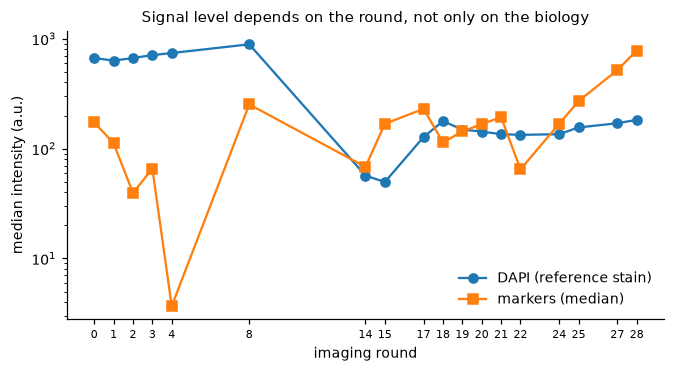

In [2]:
dapi_columns = clean.var.loc[
    clean.var.index[(clean.var.channel == "DAPI") & (clean.var.statistic == "mean_intensity")]
].sort_values("round").index

dapi = pd.Series(
    np.median(np.asarray(clean[:, list(dapi_columns)].X), axis=0),
    index=clean.var.loc[dapi_columns, "round"].astype(int).values, name="median DAPI",
)

marker_cols = analysis.marker_columns(clean.var)
marker_median = pd.Series(
    np.median(np.asarray(clean[:, marker_cols].X), axis=0),
    index=clean.var.loc[marker_cols, "round"].astype(int).values,
).groupby(level=0).median()

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(dapi.index, dapi.values, marker="o", label="DAPI (reference stain)")
ax.plot(marker_median.index, marker_median.values, marker="s", label="markers (median)")
ax.set(xlabel="imaging round", ylabel="median intensity (a.u.)", yscale="log",
       title="Signal level depends on the round, not only on the biology")
ax.set_xticks(dapi.index)
ax.tick_params(axis="x", labelsize=7)
ax.legend()

The nuclei did not change between rounds. The measurement did.

So a heatmap that puts a round-2 marker next to a round-27 marker, or a PCA over the
whole panel, is partly ranking markers by *when they were imaged*. Two things follow:

- **compare a marker to itself across conditions**, never one marker's absolute level to
  another's;
- **centre every marker on its own controls**, which is Step 17.

## Step 16 · Is any condition an outlier?

Before normalising, look at the conditions as a whole. Unsupervised methods are
obedient: hand them one sample that differs from everything else and they will spend
their first component describing it.

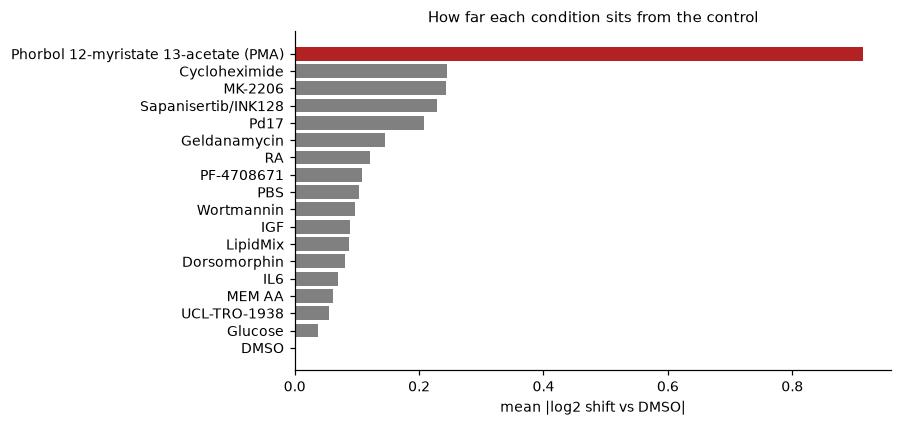

In [3]:
wells = analysis.by_well(clean, marker_cols, name_by="marker")
names = [clean.var.loc[c, "marker"] for c in marker_cols]

logged = np.log2(wells[names] + 1)
centred = logged - logged[wells.condition == "DMSO"].mean()
spread = centred.groupby(wells.condition).mean().abs().mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colours = ["firebrick" if v == spread.index[0] else "0.5" for v in spread.index]
ax.barh(range(len(spread)), spread.values, color=colours)
ax.set(yticks=range(len(spread)), yticklabels=spread.index,
       xlabel="mean |log2 shift vs DMSO|", title="How far each condition sits from the control")
ax.invert_yaxis()

Here we show the mean marker intensity (all markers) deviation by condition, with DMSO as the zero.


**PMA moves every marker, by a lot** — several times further than anything else. Phorbol esters drive naive human ES
cells out of pluripotency, so could be biologically reasonable; however it is still
an outlier statistically.

:::{important}
Thus we need to make a decision :

- **keep PMA** and it dominates the first component of every embedding, so the plot
  describes PMA-vs-everything rather than the structure among the other seventeen;
- **drop PMA** and you lose a real, strong biological effect;
- **flag it and analyse it knowingly**, which is what this course does.

What you must not do is leave it in silently and then interpret component 1 as if it
were about subtle signaling differences.
:::

#### Marking the cells coming from the PMA condition
We can mark these cells in the anndata object, in order to better disntinguish it during analysis.

In [5]:
clean.obs["is_outlier_condition"] = clean.obs.condition.astype(str).eq(
    "Phorbol 12-myristate 13-acetate (PMA)"
)
print(f"  flagged {clean.obs.is_outlier_condition.sum():,} cells in "
      f"{clean.obs.loc[clean.obs.is_outlier_condition, 'well'].nunique()} wells")

  flagged 35,984 cells in 12 wells


## Step 17 · Normalization: Set the origin and the unit

Normalising requires **two** steps. The **origin** says what counts as zero. The **unit** says what counts
as one. They answer different questions, they can be estimated from different cells, and
here they have to be.

### The formula

$$
z \;=\; \frac{\log_2(x + 1) \;-\; B_{36}}{S}
$$

**In one sentence:** how far this cell sits from an untreated cell at the *start* of the
experiment, counted in units of how much untreated cells normally differ from each other.

| symbol | what it is | Fibronectin |
|---|---|---|
| $x$ | the measured mean intensity of one marker in one cell | 120 |
| $B_{36}$ | **the origin** — median of that marker in control cells at 36 h | 5.88 |
| $S$ | **the unit** — spread of control cells about their own group, pooled over the plate | 0.71 |
| $z$ | the answer, in **control SDs** | **+1.47** |

```{image} ../../images/normalisation_formula.png
:alt: The three steps of the normalisation, shown on Fibronectin control cells at 36 h.
:width: 100%
```

**Why each piece is there**

- **$\log_2(x+1)$** — intensities multiply rather than add, so a doubling should look the
  same whether it is 50→100 or 500→1000. The $+1$ is there because a marker that is switched
  off reads exactly 0 and $\log_2 0$ is undefined; $\log_2(0+1) = 0$ sends "no signal"
  cleanly to zero. To go back: $x = 2^{z S + B_{36}} - 1$.
  
- **$-\,B_{36}$** — one fixed starting line, so the controls' own development across 36–84 h
  stays visible. Subtract each timepoint's *own* controls instead and every timepoint reads
  zero by construction — you cannot measure a change against a reference that moves with it.

  
- **$\div\,S$** — puts every marker in the same units, so a bright marker and a dim one can
  sit on the same axis. One unit is one typical cell-to-cell difference among untreated cells.


:::{note}
**Two refinements the code makes.** There are two vehicle controls, so $B_{36}$ is the
*average of the DMSO and PBS medians* rather than one pooled median — the two are not
interchangeable. And $S$ is built from each control cell's deviation from **its own vehicle
at its own timepoint** before pooling, so neither the drift across time nor the gap between
the vehicles is counted as spread.
:::

:::{tip}
**One ruler, everywhere.** $B_{36}$ and $S$ are each a single number per marker, used for
every cell at every timepoint. That is what lets all four timepoints share one UMAP: the same
measurement always gives the same number, so a GATA4-positive cell is a GATA4-positive cell
whether it was fixed at 36 h or 84 h.
:::


### The origin — the controls at the *first* timepoint

The obvious move is to centre each timepoint on its own control wells. It is also the one
mistake this step exists to prevent.

**A moving origin cannot show movement.** Centre every timepoint on its own controls and
the control sits at zero at 36 h, zero at 60 h and zero at 84 h — not because nothing
happened to it, but because you defined it that way. What survives is "different from the
control *at the same moment*", which is a fair question and not the one a time course
asks. The controls' own development — the thing that 36 to 84 hours was for — would be
gone before the first plot.

So the origin is fixed **once** (**$-\,B_{36}$**), from the control cells at the first timepoint. Zero means
*an untreated cell at the start of the experiment*, and every other cell — control or
treated, early or late — is measured from that one point.

**Does one origin still remove the round-to-round drift from Step 15?** It does, and the
plate layout is the reason. All four timepoints sit on the **same plate** and go through
the same eighteen rounds: the cells were treated at staggered times and fixed together, so
p-S6 in a 36 h well and p-S6 in an 84 h well were stained in the same round, in the same
buffer, on the same day.

The drift is therefore **one number per marker, shared by every timepoint**, and a single
subtraction removes it everywhere.

### The unit — the spread of the controls, across the whole plate

The unit wants as many control cells as it can get, so that it is stable. But "the spread
of all control cells pooled" is too much: pooled naively it would also contain the drift
across time and the gap between the two vehicles, and both would be counted as noise.
Anything later measured in a unit that wide is quietly shrunk.

So take each control cell's deviation **from the median of its own group at its own
timepoint** (**$\div\,S$**), and pool those instead. The unit becomes the spread of a control cell about
its own group: plate-wide and stable, without the two things that are not spread.

:::{extra}
:class{dropdown}
### Why median and not mean, and why SD and not the MAD

Single-cell intensity distributions have long right tails, and debris, doublets and dying
cells live in them. A mean follows them; a median does not. So the **origin** is a median,
and it should be.

The obvious next step is to make the **unit** robust in the same way, with the median
absolute deviation (MAD).

The MAD is decided entirely by the middle half of the data. If more than half the cells
share a value, it is **exactly zero**, however the rest behave. That is not a hypothetical
in 4i: a marker that is not expressed reads at background in most cells. On this plate
**GATA4 sits at exactly zero in 69% of control cells** and **p21 in 53%**, so their MADs
came out `0.000` and `0.006` against standard deviations of `2.25` and `1.58`. The guard
further down deletes a column with no spread, so GATA4 — the most dynamic marker in the
whole panel — was silently replaced by zeros, and p21's values were inflated about
260-fold.

| unit | spread of the control block | dead columns | worst \|z\| |
|---|---|---|---|
| 1.4826 × MAD | **45.7** | **1** | **1934** |
| standard deviation | **1.13** | 0 | 14 |

So the unit is a **standard deviation** of those deviations. It is the less robust
estimator and the right one here, because the two failure modes are not comparable: a few
bright cells make an SD somewhat too wide, which understates effects gradually and in the
conservative direction, while a MAD on a switching marker goes to zero, which destroys it.
**What the MAD is built to ignore is exactly where a marker that switches on keeps its
signal.**

:::


### Controls

DMSO and PBS are both controls, and between them they cover **seven plate rows** rather
than four. They are not interchangeable, though:
[chapter 07](../2_controls/07_umap.ipynb) finds 11 of the 38 markers separating them by
more than a control SD. So each vehicle contributes its own median, the origin is the
average of the two, and the gap between them never gets into the unit.


In [6]:
# Here we apply the normalisation 
values = analysis.normalise_cells(clean, marker_cols)
print(f"  {values.shape[0]:,} cells x {values.shape[1]} markers, {values.dtype}")
print(f"  origin: {', '.join(analysis.CONTROLS)} cells at {min(clean.obs.timepoint_h.astype(int))} h")

  653,472 cells x 38 markers, float32
  origin: DMSO, PBS cells at 36 h


If you wanna explore the code for normalization is in the github repository of the course under: src/mcs2026/analysis.py

### Watch it work, on three markers that should move

**GATA4**, **Fibronectin** and **Calreticulin** are all expected to rise as the system develops — endoderm specification, matrix deposition, and the secretory load that comes with it. They were also stained in rounds **2, 22 and 28**, spread right across the run, which is the second reason to pick them: if all three still trace a clean course in time, round order is not what you are looking at.

Both rows are summarised **per well**, because the well is the replicate unit and because a cell median is the wrong summary for a marker that is simply absent from most cells. GATA4 is negative in more than half the control cells at every timepoint, so its cell median sits at zero however many cells have switched on. A well mean counts them.

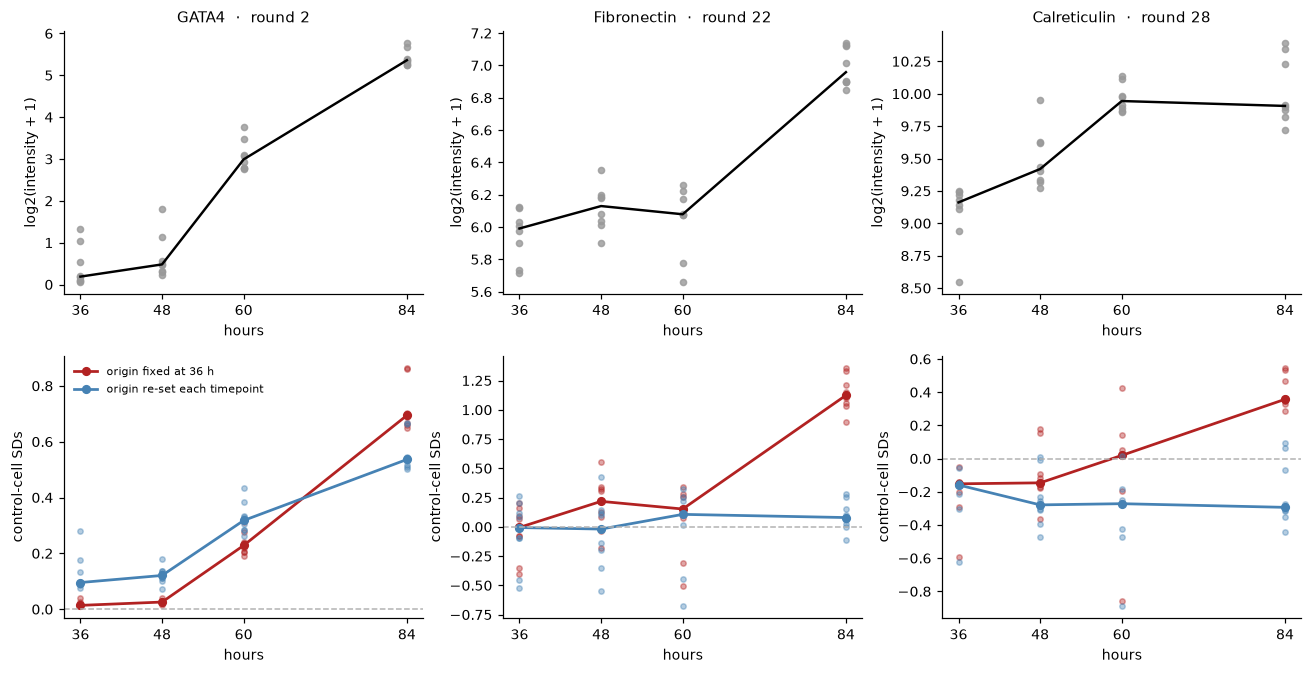

In [8]:
controls = clean.obs.condition.astype(str).isin(analysis.CONTROLS).values
timepoint = clean.obs.timepoint_h.astype(int).values

WATCH = ["GATA4", "Fibronectin", "Calreticulin"]
watch_cols = [c for c in marker_cols if clean.var.loc[c, "marker"] in WATCH]
names = [clean.var.loc[c, "marker"] for c in marker_cols]
hours = sorted(set(timepoint))

# The recipe this chapter argues against, without reimplementing it: normalising one
# timepoint at a time *is* centring on that timepoint's own controls, because within a
# single timepoint "the first timepoint" is that timepoint. `clean[rows]` is a view, so
# this costs one 38-column block per timepoint rather than a copy of the wide table.
per_timepoint = np.zeros_like(values)
for value in hours:
    rows = timepoint == value
    per_timepoint[rows] = analysis.normalise_cells(clean[rows], marker_cols)


# Everything below is summarised per well, the replicate unit. A cell median would be the
# wrong summary here: GATA4 is simply absent from more than half the control cells at
# every timepoint, so its cell median stays at zero no matter how many cells switch on.
# A well mean counts them.
def control_wells(matrix):
    block = ad.AnnData(X=matrix, obs=clean.obs.copy(), var=pd.DataFrame(index=names))
    table = analysis.by_well(block)
    return table[table.condition.isin(analysis.CONTROLS)]

fixed_origin, moving_origin = control_wells(values), control_wells(per_timepoint)
raw = analysis.by_well(clean, watch_cols, name_by="marker")
raw = raw[raw.condition.isin(analysis.CONTROLS)]

fig, axes = plotting.panel_grid(6, ncols=3, size=(4.0, 3.1))
for k, column in enumerate(watch_cols):
    name = clean.var.loc[column, "marker"]

    ax = axes[k]
    logged = np.log2(raw[name] + 1)
    ax.plot(raw.timepoint, logged, "o", color="0.6", ms=4, alpha=0.8)
    ax.plot(hours, [logged[raw.timepoint == h].median() for h in hours],
            "-", color="black", lw=1.6)
    ax.set(title=f"{name}  ·  round {int(clean.var.loc[column, 'round'])}",
           xlabel="hours", ylabel="log2(intensity + 1)", xticks=hours)

    ax = axes[k + 3]
    for label, table, colour in [
        ("origin fixed at 36 h", fixed_origin, "firebrick"),
        ("origin re-set each timepoint", moving_origin, "steelblue"),
    ]:
        ax.plot(table.timepoint, table[name], "o", color=colour, ms=3.5, alpha=0.4)
        ax.plot(hours, [table.loc[table.timepoint == h, name].median() for h in hours],
                "o-", color=colour, lw=1.8, ms=5, label=label)
    ax.axhline(0, color="0.7", lw=1, ls="--")
    ax.set(xlabel="hours", ylabel="control-cell SDs", xticks=hours)
    if k == 0:
        ax.legend(fontsize=7.5, loc="best")
fig.tight_layout()

**Top row — the measurement.** Absolute level in log2 intensity, before anything has been
done to it. The three markers sit at quite different heights, and that is the round they
were stained in rather than the biology. It is exactly what subtracting one origin per
marker is for.

**Bottom row — the same three markers, the two recipes.** For **Fibronectin** and
**Calreticulin** the blue trace is flat while the red one climbs. Here we see the difference that makes centering on the first timepoint controls vs on the owns timepoint controls.

**GATA4 is the interesting exception, and worth the paragraph.** There both traces rise.
The reason is that GATA4 is *off* in most control cells, so the control median sits on the
floor at every timepoint — and a moving origin can only erase what the origin is able to
move to. When the whole population shifts, re-centring takes the shift with it; when a
minority switches on from zero, the median never notices, so there is nothing for the
re-centring to remove.

That is the useful version of the lesson. The per-timepoint recipe does not flatten
everything uniformly — it flattens exactly the changes you are most likely to care about
in a time course, and leaves a misleading impression of safety on the ones it misses.



## Step 19 · Assemble the clean object

Everything Stage 1 established is currently scattered: the values are in one file, the
decoder in a `var` table, the dropped wells in a `uns` entry, and the normalisation only
exists as a well-level DataFrame that lives in this notebook's memory.

This step puts it in one object, so that every chapter after this one begins with a
single `read_h5ad` and no set-up.

```{image} ../../images/clean_object_light.svg
:class: only-light
:alt: The clean AnnData: X holding normalised values, a raw layer, an annotated var table, a tidy obs table, and provenance in uns.
```
```{image} ../../images/clean_object_dark.svg
:class: only-dark
:alt: The clean AnnData: X holding normalised values, a raw layer, an annotated var table, a tidy obs table, and provenance in uns.
```

### Which columns go in it?

2,587 features survived Step 9. The object carries **38** of them — one mean intensity per
antibody per cell. That is a large cut and it needs an argument, not a preference.

In [14]:
counts = clean.var.family.value_counts()
pd.DataFrame({"columns": counts, "% of the table": (100 * counts / counts.sum()).round(1)})

,columns,% of the table
family,,
Texture,2262,87.4
Intensity,280,10.8
Population,23,0.9
Morphology,22,0.9


**A feature set votes by column count.** Texture is most of what survived, so it decides
most of anything computed from all of it. That is a claim, so measure it — cheaply, at the
well level, where the whole table is 223 rows.

In [15]:
everything = clean.var.index.tolist()
well_wide = analysis.by_well(clean, everything)
# abs() because Morphology_orientation is an angle and reaches -1.57; log2 of that
# would be NaN. It is the one non-positive column in the table.
logged = np.log2(np.abs(well_wide[everything]) + 1)

reference = logged[(well_wide.condition == "DMSO").values]
# A column with no spread across the control wells carries no information here, and
# dividing by its zero would give infinities that fillna does not catch.
spread = reference.std().replace(0, np.nan)
scaled = (((logged - reference.mean()) / spread)
          .replace([np.inf, -np.inf], np.nan).fillna(0))

survey = ad.AnnData(scaled.to_numpy(dtype="float32"))
sc.pp.pca(survey, n_comps=2, random_state=0)
weight = (pd.Series(np.abs(survey.varm["PCs"][:, 0]), index=everything)
          .groupby(clean.var.family, observed=True).sum())
pd.DataFrame({
    "% of columns": (100 * counts / counts.sum()).round(1),
    "% of PC1's loading": (100 * weight / weight.sum()).round(1),
}).sort_values("% of columns", ascending=False)

,% of columns,% of PC1's loading
family,,
Texture,87.4,89.599998
Intensity,10.8,9.100000
Morphology,0.9,0.800000
Population,0.9,0.600000


**Read the two columns against each other.** Each family contributes to the first component
in almost exactly the proportion of columns it has — not in proportion to how much it
knows. Feed a method everything and you have not asked it an open question; you have voted
for texture 2,262 times.

**And most of those columns repeat each other.** Each marker carries 58 texture features.
How many independent numbers is that really?

In [16]:
one_marker = clean.var.index[(clean.var.family == "Texture") & (clean.var.marker == "LAMP1")]
block = ad.AnnData(scaled[list(one_marker)].to_numpy(dtype="float32"))
sc.pp.pca(block, n_comps=min(block.n_vars, block.n_obs) - 1, random_state=0)
spectrum = block.uns["pca"]["variance_ratio"]

correlation = scaled[list(one_marker)].corr().abs().values
np.fill_diagonal(correlation, np.nan)
print(f"  LAMP1 has {len(one_marker)} texture columns")
print(f"  median |correlation| between them: {np.nanmedian(correlation):.2f}")
print(f"  components reaching 90% of their variance: {(np.cumsum(spectrum) < 0.9).sum() + 1}")

  LAMP1 has 58 texture columns
  median |correlation| between them: 0.89
  components reaching 90% of their variance: 2


Fifty-eight columns, and single figures of real dimension between them. The block
is wide, not deep.

:::{important}
**What this gives up, stated plainly.** Texture is not noise. It measures something the
mean cannot — *how* a protein is arranged rather than how much of it there is — and for
several markers on this plate that is where the effect lives: the mean barely moves while
the texture of the same marker shifts by several control SDs. A compound that redistributes
a protein without changing its abundance is invisible to every number in this object.

This course asks the first question. "How much of each protein is in this cell" is
answerable with 38 interpretable numbers, every one of which reads back to an antibody, and
a component you cannot name is a component you cannot report.

The wide table stays on disk as `mcs2026_slim.h5ad` and the door is open. Three things
will bite you when you walk through it: `Morphology_orientation` is an angle in radians, so
it has no mean and no meaningful z-score; `Population_mean_distance_nn_50` and `_100`
already contain NaNs; and Haralick correlations are roughly symmetric while Laws energies
are skewed like intensities, so no single transform is right for all of them.
:::

In [17]:
marker_cols = analysis.marker_columns(clean.var)
marker_names = clean.var.loc[marker_cols, "marker"].tolist()
print(f"{len(marker_cols)} markers, one column each")
print(f"  {', '.join(marker_names[:10])} …")

38 markers, one column each
  beta-Catenin, Foxo3a, FGFR1, Nanog, Oct4, GATA4, p-MyosinIIa, GATA6, Sox2, EEA1 …


### Build it

`X` is already normalised — that happened once, in Step 17 — so the object is assembled
around values that exist. Five slots, each with a job:

| slot | what goes in it |
|---|---|
| `X` | the normalised values — control-cell SDs from an origin at the first timepoint |
| `layers["raw"]` | the intensities as measured, so nothing is thrown away |
| `var` | marker, channel, round, family, theme, thresholds — the decoder from Step 7 |
| `obs` | well, row, column, condition, timepoint, replicate, area, DAPI |
| `uns["provenance"]` | what was dropped, why, and how the numbers were made |

In [18]:
cleaned.layers["raw"] = np.asarray(clean[:, marker_cols].X, dtype="float32")

**`replicate`** is the one piece of metadata the plate implies but never states: which
of the three (or five) wells of a condition × timepoint this cell came from. Every
statistical test in Part 4 counts wells, so the number is worth having explicitly.

In [19]:
well_key = (cleaned.obs[["condition", "timepoint_h", "well"]]
            .drop_duplicates()
            .sort_values(["condition", "timepoint_h", "well"]))
well_key["replicate"] = (well_key.groupby(["condition", "timepoint_h"], observed=True)
                         .cumcount() + 1)
cleaned.obs["replicate"] = (cleaned.obs.well.astype(str)
                            .map(dict(zip(well_key.well.astype(str), well_key.replicate)))
                            .astype("int8"))
well_key.groupby("condition", observed=True).replicate.max().rename("wells per timepoint")

condition
DMSO                                     5
PBS                                      3
Cycloheximide                            3
Dorsomorphin                             3
Geldanamycin                             3
Glucose                                  3
IGF                                      3
IL6                                      3
LipidMix                                 3
MEM AA                                   3
MK-2206                                  3
PF-4708671                               3
Pd17                                     3
Phorbol 12-myristate 13-acetate (PMA)    3
RA                                       3
Sapanisertib/INK128                      3
UCL-TRO-1938                             3
Wortmannin                               3
Name: wells per timepoint, dtype: int64

Two more per-cell numbers are worth carrying across. Neither is a marker — **area** is a
shape measurement and **DAPI** is the counterstain imaged in every round — so neither
belongs in `X` alongside the antibodies. But both explain things the markers cannot: how
big a cell is, and how brightly it stained overall. They go in `obs`.

In [20]:
area_column = clean.var.index[(clean.var.family == "Morphology")
                              & (clean.var.statistic == "area")][0]
dapi_column = clean.var.index[(clean.var.channel == "DAPI")
                              & (clean.var.statistic == "mean_intensity")
                              & (clean.var["round"] == 0)][0]
cleaned.obs["area"] = np.asarray(clean[:, area_column].X).ravel()
cleaned.obs["dapi"] = np.asarray(clean[:, dapi_column].X).ravel()
cleaned.obs[["area", "dapi"]].describe().loc[["mean", "std", "min", "max"]].round(1)

,area,dapi
mean,4035.6,727.5
std,3720.1,421.4
min,29.0,0.0
max,57126.0,7669.8


### Write down what happened to it

In six months you will open this file and not remember whether the border cells came
out, or which well was dropped and why. Neither will whoever you send it to. `uns` is
where that goes.

In [21]:
cleaned.uns["provenance"] = {
    **clean.uns.get("provenance", {}),
    "built_by": "Multicellular Systems 2026, Part 3 Stage 1, chapter 03",
    "built_on": date.today().isoformat(),
    "layout_workbook": LAYOUT_XLSX.name,
    "cells_removed": "border cells — is_border_external or is_border_internal",
    "wells_removed": "; ".join(f"{w}: {why}" for w, why in clean.uns["dropped_wells"].items()),
    "features": f"{len(marker_cols)} marker mean intensities, decoded from 4,464 raw columns",
    "X": ("log2(x + 1); origin = median of the DMSO+PBS cells at the first timepoint, "
          "unit = SD of control cells about their own vehicle x timepoint median"),
    "layers_raw": "mean intensity as measured",
    "units": "control-cell standard deviations",
}
for key, value in cleaned.uns["provenance"].items():
    print(f"  {key:18s} {value}")

  ABs                Ab1
  Barcode            HNES1-MP-PL-1
  Cell_line          CBA
  Path               /tungstenfs/scratch/gliberal/Users/suppsimo/HUMAN/Moldev/001_001_MD-4i_Multiplexing_ScreenFollowup/HNES1_MP_PL_1/CombinedRounds/R_Basics_0_1_2_3_4_8_14_15_17_18_19_20_21_22_24_25_27_28/HNES1_MP_PL1_mip.zarr
  built_by           Multicellular Systems 2026, Part 3 Stage 1, chapter 03
  built_on           2026-09-14
  layout_workbook    L_ayout_384_Haralick_Thresholds.xlsx
  cells_removed      border cells — is_border_external or is_border_internal
  wells_removed      B23: 9% of its timepoint median cell count; next-lowest well (I23) is 46%
  features           38 marker mean intensities, decoded from 4,464 raw columns
  X                  log2(x + 1); origin = median of the DMSO+PBS cells at the first timepoint, unit = SD of control cells about their own vehicle x timepoint median
  layers_raw         mean intensity as measured
  units              control-cell standard deviations


### Save

In [22]:
cleaned.write_h5ad(H5AD_SLIM.with_name("mcs2026_clean.h5ad"), compression="gzip")
normalised.to_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
cleaned

AnnData object with n_obs × n_vars = 653472 × 38
    obs: 'label', 'well_name', 'ROI', 'is_border_internal', 'is_border_external', 'Organoid_ID', 'timepoint_h', 'condition', 'condition_code', 'well', 'row', 'column', 'is_outlier_condition', 'replicate', 'area', 'dapi'
    var: 'family', 'statistic', 'channel', 'round', 'marker', 'species', 'intensity_threshold', 'haralick_threshold', 'failed', 'is_reference', 'is_structural', 'theme', 'column'
    uns: 'provenance'
    layers: 'raw'

:::{tip}
**Two files, two jobs.** `mcs2026_clean.h5ad` is one row per **cell** — embeddings,
clustering, single-cell distributions. `mcs2026_wells.parquet` is one row per **well**,
already averaged — every statistical test, because the well is what was independently
treated. Reaching for the wrong one is the single most common mistake in Part 3, and
[chapter 08](../2_controls/08_cell_type_annotation.ipynb) shows what it costs.
:::

## Stage 1 complete

| | |
|---|---|
| **started with** | 733,556 × 4,464, `var` empty, 13.1 GB |
| **removed** | border cells (~11%), one well, redundant DAPI and duplicated structural blocks |
| **ended with** | `mcs2026_clean.h5ad` — every surviving cell × 38 named markers |
| **units** | control-cell SDs, from a fixed origin at the first timepoint |
| **and** | `mcs2026_wells.parquet`, the same thing averaged to one row per well |

One chapter of Stage 1 remains: [04 · Subsetting and
sketching](04_subsetting_and_sketching.ipynb) cuts this down to something a neighbour
graph can be built on, without throwing away the rare cells.

---

## Exercises

### 1. What does a moving origin cost you?

Re-run the normalisation the way this chapter argues against — each timepoint centred on
its own controls — and compare. Does the INK128 / p-S6 result survive? What happens to
the controls themselves?

:::{admonition} Solution
:class: dropdown

Normalising each timepoint as if it were its own experiment is exactly the old recipe,
because within a single timepoint "the first timepoint" is that timepoint:

```python
per_timepoint = np.zeros_like(values)
for value in sorted(set(timepoint)):
    rows = timepoint == value
    per_timepoint[rows] = analysis.normalise_cells(clean[rows], marker_cols)

for value in sorted(set(timepoint)):
    block = per_timepoint[controls & (timepoint == value)]
    print(value, round(float(np.abs(np.median(block, axis=0)).mean()), 3))
```

**The drug result survives untouched.** `compare_to_control` compares treated against
control *within* a timepoint, and a shared offset cancels in a difference — the ranks do
not move, so the p-values are identical either way.

What disappears is the controls' trajectory: every timepoint now prints ~0, because that
is what you asked for. The cost is invisible in any single-timepoint comparison, which is
precisely why it is easy to ship. It only shows up later, in
[chapter 10](../2_controls/10_diffusion_map.ipynb), when a trajectory is supposed to run
from 36 h to 84 h and there is nothing left for it to run along.
:::

### 2. Should both vehicles be in the reference?

The origin is the average of the DMSO and PBS medians. Rebuild it from DMSO alone and
see which markers move, and by how much.

:::{admonition} Solution
:class: dropdown

```python
dmso_only = analysis.normalise_cells(clean, marker_cols, controls=("DMSO",))
moved = pd.Series(np.median(dmso_only, axis=0) - np.median(values, axis=0), index=names)
print(moved.abs().sort_values(ascending=False).head(5).round(2))
```

The markers that move are the ones where the two vehicles disagree, and the shift is
about half the gap between them — because two references average, and one does not.

Both choices are defensible. Both vehicles gives more reference cells and covers seven
plate rows instead of four; DMSO alone ties zero to the solvent the compounds were
actually dissolved in, which is the comparison a pharmacologist would want. What is not
defensible is not knowing which one you did — which is why it is written into
`uns["provenance"]` rather than left in a notebook.
:::

### 3. How large is a real effect, in this experiment?

Using `analysis.rank_effects`, list the ten largest condition × marker shifts. How many
exceed 3 control SDs? Compare that with the unit those SDs are measured in — Step 17
sets one control SD to the standard deviation of the control cells about their own group,
so a shift of 3 means three times the spread of a single untreated cell.

:::{admonition} Solution
:class: dropdown

```python
ranked = analysis.rank_effects(normalised, names)
print(ranked.head(10).round(2))
print(f"beyond 3 control SDs: {(ranked.abs_shift > 3).sum()} of {len(ranked)}")
```

A handful of pairs exceed 3 SDs and most sit well under 1. That ratio is the honest
picture of a screen: a few strong, specific effects against a background of very little,
and it is why ranking by effect size in control SDs is more informative than sorting by
p-value.
:::

---

**Next:** [04 · Subsetting and sketching](04_subsetting_and_sketching.ipynb).